# CNN training notebook — annotated version

This notebook trains and evaluates a small binary CNN for **person vs. non-person**
classification. The main target is a compact model that can be compared with, or
eventually deployed to, a hardware/FPGA-oriented implementation.

## Recommended reading order

1. Prepare the dataset folders.
2. Understand the preprocessing pipeline.
3. Review the legacy/experimental models.
4. Use the **main hardware-aware training pipeline** as the final training block.
5. Analyze validation performance using the confusion matrix, histograms, threshold
   sweep, and misclassified-image visualization.

## Important note

Some cells are kept as earlier experiments or optional utilities. They are now labeled
clearly so you can decide whether to run them. The notebook logic itself was not
intentionally changed; the edits are comments, explanations, and clearer section text.

## 1. Dataset resources

These cells prepare the input dataset inside Google Colab.  
The expected folder structure is:

```text
/content/
  non_person/
  person/
```

Keras will infer labels from these two folder names.

### Raw dataset archive files

The following shell cells unzip the original dataset archives.

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Unzip the non-person image dataset into the Colab `/content` directory.
# -----------------------------------------------------------------------------
!unzip /content/drive/MyDrive/embedded/non_person.zip -d /content

Archive:  /content/drive/MyDrive/embedded/non_person.zip
  inflating: /content/non_person/non_person_00025.png  
  inflating: /content/non_person/non_person_00743.png  
  inflating: /content/non_person/non_person_00757.png  
  inflating: /content/non_person/non_person_00031.png  
  inflating: /content/non_person/non_person_00019.png  
  inflating: /content/non_person/non_person_00958.png  
  inflating: /content/non_person/non_person_00780.png  
  inflating: /content/non_person/non_person_00794.png  
  inflating: /content/non_person/non_person_00541.png  
  inflating: /content/non_person/non_person_00227.png  
  inflating: /content/non_person/non_person_00233.png  
  inflating: /content/non_person/non_person_00555.png  
  inflating: /content/non_person/non_person_00569.png  
  inflating: /content/non_person/non_person_00582.png  
  inflating: /content/non_person/non_person_00596.png  
  inflating: /content/non_person/non_person_00435.png  
  inflating: /content/non_person/non_person_003

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Unzip the person image dataset into the Colab `/content` directory.
# -----------------------------------------------------------------------------
!unzip /content/drive/MyDrive/embedded/person.zip -d /content/

Archive:  /content/drive/MyDrive/embedded/person.zip
  inflating: /content/person/person_00088.png  
  inflating: /content/person/person_00936.png  
  inflating: /content/person/person_00922.png  
  inflating: /content/person/person_00077.png  
  inflating: /content/person/person_00711.png  
  inflating: /content/person/person_00705.png  
  inflating: /content/person/person_00063.png  
  inflating: /content/person/person_00739.png  
  inflating: /content/person/person_00513.png  
  inflating: /content/person/person_00275.png  
  inflating: /content/person/person_00261.png  
  inflating: /content/person/person_00507.png  
  inflating: /content/person/person_00249.png  
  inflating: /content/person/person_00498.png  
  inflating: /content/person/person_00467.png  
  inflating: /content/person/person_00301.png  
  inflating: /content/person/person_00315.png  
  inflating: /content/person/person_00473.png  
  inflating: /content/person/person_01023.png  
  inflating: /content/person/person

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: List `/content` to quickly verify that both class folders are present.
# -----------------------------------------------------------------------------
!ls /content/

drive  non_person  person  sample_data


## 2. Initial dataset loading and preprocessing

This block loads the image folders with `image_dataset_from_directory`, splits the
data into training and validation subsets, converts RGB images to grayscale, and
normalizes pixel values from `[0, 255]` to `[0, 1]`.

The class order is fixed manually:

- `non_person` → `0`
- `person` → `1`

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Load the dataset, create train/validation splits, convert images to grayscale, and normalize pixels.
# Note: This is an initial loader; later sections contain a more hardware-matched pipeline.
# -----------------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 32
BATCH_SIZE = 32
SEED = 42

DATASET_DIR = "/content/Untitled Folder"
DATASET_DIR = "/content/"

CLASS_NAMES = ["non_person", "person"]
# non-person -> 0
# person     -> 1

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    shuffle=True
)

def preprocess(image, label):
    # RGB -> grayscale
    image = tf.image.rgb_to_grayscale(image)

    # [0, 255] -> [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

Found 1989 files belonging to 2 classes.
Using 1592 files for training.
Found 1989 files belonging to 2 classes.
Using 397 files for validation.


## 3. Optional resize experiment

This cell downscales the dataset after loading. It is useful for testing very small
models, but be careful: any model defined after this cell must use the same input
shape as the resized images.

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Resize dataset images to a smaller input size for tiny-CNN experiments.
# Note: The comment in the original notebook said 32x32, but this code resizes to 16x16.
# -----------------------------------------------------------------------------
def resize_images(image, label):
    # Resize image to 16x16 for a tiny input experiment.
    image = tf.image.resize(image, (32, 32))
    return image, label

train_ds = train_ds.map(resize_images)
val_ds = val_ds.map(resize_images)


## 4. Legacy 64×64 CNN baseline

This is an earlier baseline model that expects `64×64×1` grayscale input.

Run this only with the 64×64 preprocessed dataset. If the previous resize cell has
already converted the dataset to smaller images, reload the dataset before training
this model.

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Define and compile a legacy 64x64 CNN baseline.
# Note: This model expects input shape `(64, 64, 1)`.
# -----------------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(4, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),   # 64 -> 32

    layers.Conv2D(8, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),   # 32 -> 16

    layers.Conv2D(16, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),   # 16 -> 8

    layers.AveragePooling2D(pool_size=(8, 8)),  # 8x8 -> 1x1

    layers.Flatten(),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 1, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,521 (5.94 KB)

 Trainable params: 1,521 (5.94 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Tiny 32×32 CNN baseline

This model is much smaller and is closer to the kind of architecture that can be
deployed on constrained FPGA hardware. It uses two small convolution layers and a
single sigmoid output for binary classification.

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Define and compile a tiny CNN for 16x16 grayscale inputs.
# Note: The model is created here; training happens in a later cell.
# -----------------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 1)),

        tf.keras.layers.AveragePooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(
            filters=1,
            kernel_size=3,
            strides=2,
            padding="same",
            activation="relu",
        ),

        tf.keras.layers.Conv2D(
            filters=2,
            kernel_size=3,
            strides=2,
            padding="same",
            activation="relu",
        ),

        tf.keras.layers.AveragePooling2D(pool_size=(4, 4)),
        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 2)        │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 4)        │            76 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 1, 4)        │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Train and save the tiny model

This cell trains the current `model` object using early stopping and saves the best
model as `new_model_32.h5`.

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Train the currently defined model and save it as `new_model_32.h5`.
# Note: Early stopping restores the best validation-loss weights before saving.
# -----------------------------------------------------------------------------
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,                        # high cap; early stop will cut it short
    callbacks=[early_stop],
)

model.save("new_model_32.h5")

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4881 - loss: 0.6949 - val_accuracy: 0.4282 - val_loss: 0.6935
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4906 - loss: 0.6919 - val_accuracy: 0.4433 - val_loss: 0.6928
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4925 - loss: 0.6894 - val_accuracy: 0.4433 - val_loss: 0.6908
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4925 - loss: 0.6861 - val_accuracy: 0.4433 - val_loss: 0.6887
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4925 - loss: 0.6818 - val_accuracy: 0.4433 - val_loss: 0.6830
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4987 - loss: 0.6764 - val_accuracy: 0.4433 - val_loss: 0.6785
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4969 - loss: 0.6701 - val_accuracy: 0.4610 - val_loss: 0.6703
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4969 - loss: 0.6619 - val_accuracy: 0.

## 8. Test the trained model on a real image

This cell applies the same preprocessing pipeline to a single external image and
visualizes the model input together with the predicted class.

Image: 5819026687574871707.jpg
P(person): 0.8356
Prediction: PERSON


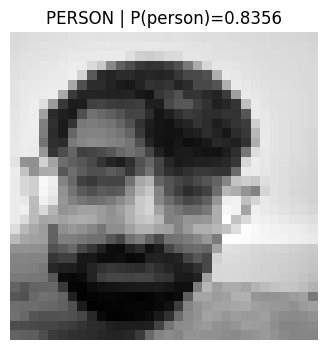

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Preprocess one external image, run inference, and display the model input.
# -----------------------------------------------------------------------------
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import os

# Same settings as training
IMG_SIZE = 32
LOAD_SIZE = 64
THRESHOLD = 0.5

def preprocess_single_image_for_model(image_path):
    """
    Same preprocessing idea as training:
    RGB image -> [0,1] -> BT.601 grayscale -> resize to IMG_SIZE x IMG_SIZE
    """

    # Load RGB image
    img = Image.open(image_path).convert("RGB")

    # Match training: load/resize first to 64x64
    img = img.resize((LOAD_SIZE, LOAD_SIZE))

    arr = np.array(img, dtype=np.float32) / 255.0

    # Hardware-style BT.601 grayscale:
    # gray = (77*R + 150*G + 29*B) / 256
    gray = (
        0.30078125 * arr[:, :, 0] +
        0.58593750 * arr[:, :, 1] +
        0.11328125 * arr[:, :, 2]
    )

    # Shape: (64, 64, 1)
    gray = gray[..., np.newaxis]

    # Resize grayscale image to the model input size, same as training
    gray = tf.image.resize(gray, (IMG_SIZE, IMG_SIZE)).numpy()

    # Add batch dimension: (1, IMG_SIZE, IMG_SIZE, 1)
    inp = gray.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    return inp, gray


def test_one_image(image_path, model, threshold=THRESHOLD):
    inp, gray = preprocess_single_image_for_model(image_path)

    score = model.predict(inp, verbose=0)[0][0]
    label = "PERSON" if score >= threshold else "NO PERSON"

    print(f"Image: {os.path.basename(image_path)}")
    print(f"P(person): {score:.4f}")
    print(f"Prediction: {label}")

    plt.figure(figsize=(4, 4))
    plt.imshow(gray.squeeze(), cmap="gray")
    plt.title(f"{label} | P(person)={score:.4f}")
    plt.axis("off")
    plt.show()

    return score, label

image_path = "/content/5819026687574871707.jpg"
# image_path="/content/2026-05-26 15.40.52.jpg"

score, label = test_one_image(image_path, model)

## 9. Debug the preprocessing visually

Use this cell when you want to confirm that the image seen by the model still
contains the information you expect after resizing and grayscale conversion.

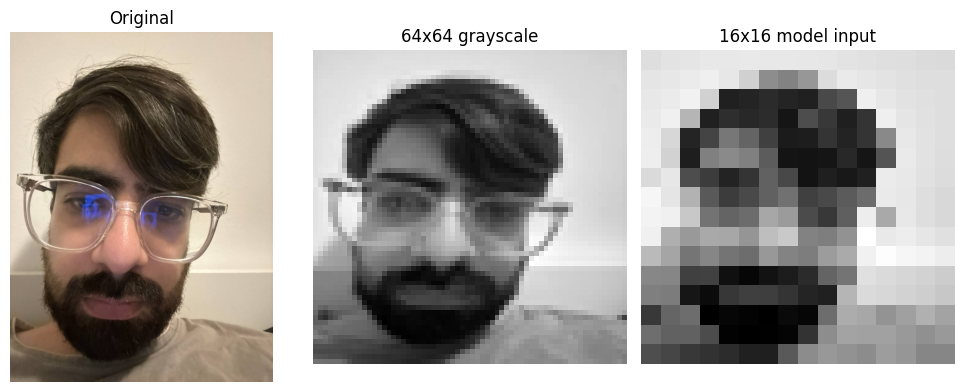

array([[0.8116996 , 0.8278799 , 0.83444774, 0.84454656, 0.8459712 ,
        0.8481196 , 0.8460287 , 0.8465111 , 0.84277344, 0.8396254 ,
        0.82858074, 0.8217027 , 0.8162416 , 0.81009495, 0.8009306 ,
        0.79624313],
       [0.8337622 , 0.8424824 , 0.855913  , 0.86836326, 0.8432177 ,
        0.76441866, 0.53357077, 0.49510956, 0.5677964 , 0.80521595,
        0.8510953 , 0.8392004 , 0.82662   , 0.81723726, 0.8127413 ,
        0.81034386],
       [0.8446423 , 0.85493255, 0.87611055, 0.7676892 , 0.16433442,
        0.17826286, 0.19734988, 0.17567019, 0.16216299, 0.30235526,
        0.3399701 , 0.86891854, 0.84258574, 0.82591915, 0.8175819 ,
        0.8108149 ],
       [0.8539522 , 0.87257963, 0.67153037, 0.16232002, 0.20662531,
        0.1915786 , 0.20521218, 0.12328815, 0.3146446 , 0.24355853,
        0.15657936, 0.23124617, 0.8706189 , 0.8362094 , 0.82297796,
        0.81277573],
       [0.86310893, 0.78888255, 0.1783433 , 0.28264785, 0.45696232,
        0.3943436 , 0.26784623, 

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Show each preprocessing stage so you can visually debug the model input.
# -----------------------------------------------------------------------------
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

IMG_SIZE = 16
LOAD_SIZE = 64

def debug_preprocess_image(image_path):
    img_original = Image.open(image_path).convert("RGB")
    img_64 = img_original.resize((LOAD_SIZE, LOAD_SIZE))

    arr = np.array(img_64, dtype=np.float32) / 255.0

    gray = (
        0.30078125 * arr[:, :, 0] +
        0.58593750 * arr[:, :, 1] +
        0.11328125 * arr[:, :, 2]
    )

    gray_16 = tf.image.resize(
        gray[..., np.newaxis],
        (IMG_SIZE, IMG_SIZE)
    ).numpy().squeeze()

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gray, cmap="gray")
    plt.title("64x64 grayscale")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(gray_16, cmap="gray")
    plt.title("16x16 model input")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return gray_16

image_path = "/content/5819026687574871707.jpg"
debug_preprocess_image(image_path)

## 10. Analyze prediction-score distribution

This histogram shows how the model scores true `person` and true `non_person`
validation samples. A good model should push the two distributions away from each
other, making threshold selection easier.

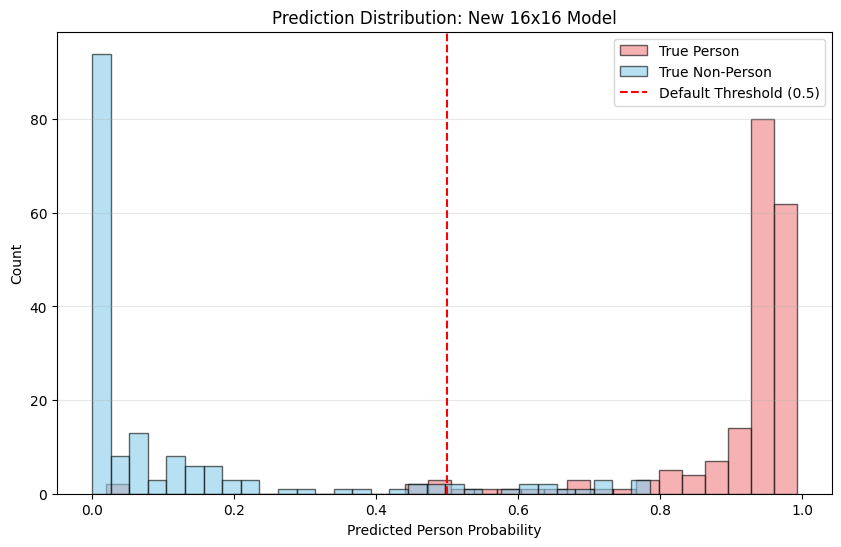

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Collect validation probabilities and plot score histograms for both classes.
# -----------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def collect_model_probs(dataset, model_to_test):
    all_labels = []
    all_probs = []

    for images, labels in dataset:
        preds = model_to_test.predict(images, verbose=0).reshape(-1)
        all_probs.extend(preds.tolist())
        all_labels.extend(labels.numpy().flatten().astype(int).tolist())


    return np.array(all_labels), np.array(all_probs)

# Collect scores for the new model
y_true_new, y_prob_new = collect_model_probs(val_ds, model)

# Split probs by class for the histogram
person_probs_new = y_prob_new[y_true_new == 1]
non_person_probs_new = y_prob_new[y_true_new == 0]

plt.figure(figsize=(10, 6))
plt.hist(person_probs_new, bins=30, alpha=0.6, color='lightcoral', label='True Person', edgecolor='black')
plt.hist(non_person_probs_new, bins=30, alpha=0.6, color='skyblue', label='True Non-Person', edgecolor='black')

plt.axvline(0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.xlabel('Predicted Person Probability')
plt.ylabel('Count')
plt.title('Prediction Distribution: New 16x16 Model')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 11. Confusion matrix and classification report

This section converts probabilities into binary predictions using a threshold and
reports the main classification metrics.

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Compute the confusion matrix and classification report at threshold 0.5.
# -----------------------------------------------------------------------------
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_prob = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0).ravel()
    y_prob.extend(probs)
    y_true.extend(labels.numpy().ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["non_person", "person"]
))

Confusion Matrix:
[[172   4]
 [  4 217]]

Classification Report:
              precision    recall  f1-score   support

  non_person       0.98      0.98      0.98       176
      person       0.98      0.98      0.98       221

    accuracy                           0.98       397
   macro avg       0.98      0.98      0.98       397
weighted avg       0.98      0.98      0.98       397



## 12. Collect false positives and false negatives

This cell stores all validation images, labels, probabilities, and predictions, then
finds the indexes of the mistakes.

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Find false-positive and false-negative validation examples.
# -----------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

THRESHOLD = 0.5   # use the same threshold you used for the confusion matrix

images_list = []
labels_list = []
probs_list = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0).ravel()

    images_list.extend(images.numpy())
    labels_list.extend(labels.numpy().ravel())
    probs_list.extend(probs)

images_list = np.array(images_list)
labels_list = np.array(labels_list).astype(int)
probs_list = np.array(probs_list)

preds_list = (probs_list >= THRESHOLD).astype(int)

false_positives = np.where((labels_list == 0) & (preds_list == 1))[0]
false_negatives = np.where((labels_list == 1) & (preds_list == 0))[0]

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")
print(f"Total mistakes : {len(false_positives) + len(false_negatives)}")

False positives: 4
False negatives: 4
Total mistakes : 8


## 13. Visualize misclassified images

This helps you understand *why* the model is making mistakes. False positives and
false negatives often reveal dataset problems, ambiguous images, or a threshold that
needs adjustment.

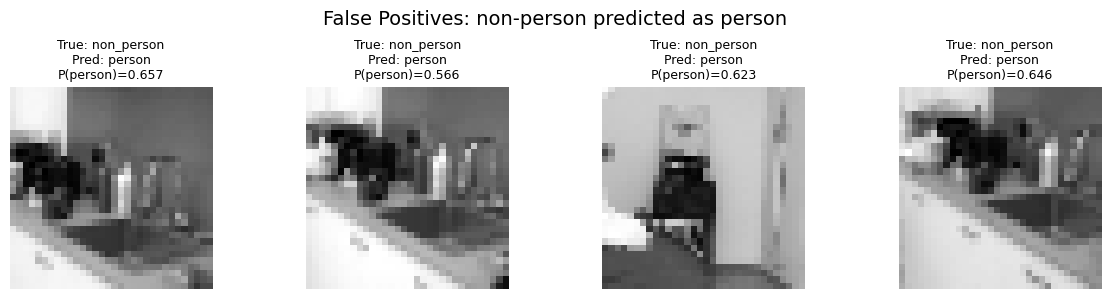

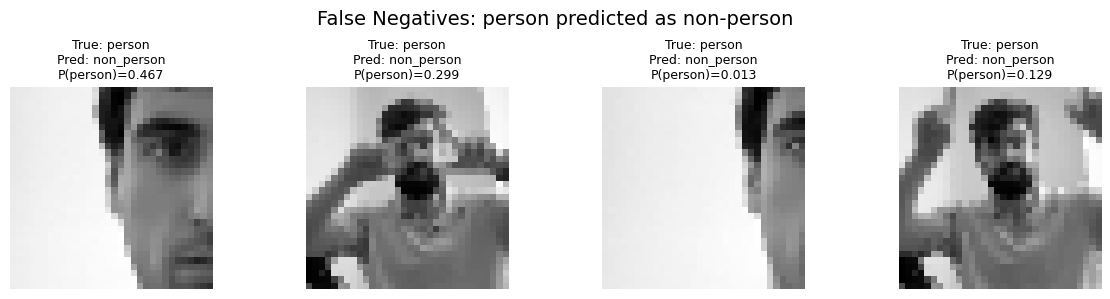

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Display misclassified validation images with true label, predicted label, and probability.
# -----------------------------------------------------------------------------
def show_misclassified(indices, title, max_images=20):
    if len(indices) == 0:
        print(f"No images found for: {title}")
        return

    n = min(len(indices), max_images)
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(cols * 3, rows * 3))

    for i, idx in enumerate(indices[:n]):
        img = images_list[idx]
        true_label = "person" if labels_list[idx] == 1 else "non_person"
        pred_label = "person" if preds_list[idx] == 1 else "non_person"
        prob = probs_list[idx]

        plt.subplot(rows, cols, i + 1)

        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img.astype("uint8"))

        plt.title(
            f"True: {true_label}\nPred: {pred_label}\nP(person)={prob:.3f}",
            fontsize=9
        )
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


show_misclassified(false_positives, "False Positives: non-person predicted as person")
show_misclassified(false_negatives, "False Negatives: person predicted as non-person")

## 14. Threshold sweep

The final classification threshold is a design choice. This cell compares different
thresholds and shows how accuracy, precision, recall, and F1 change.

In [ ]:
# -----------------------------------------------------------------------------
# Purpose: Evaluate several thresholds to compare accuracy, precision, recall, and F1.
# -----------------------------------------------------------------------------
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

for threshold in [0.50, 0.45, 0.40, 0.35, 0.30]:
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nThreshold: {threshold:.2f}")
    print(cm)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")


Threshold: 0.50
[[165  11]
 [ 35 186]]
Accuracy : 0.8841
Precision: 0.9442
Recall   : 0.8416
F1-score : 0.8900

Threshold: 0.45
[[162  14]
 [ 34 187]]
Accuracy : 0.8791
Precision: 0.9303
Recall   : 0.8462
F1-score : 0.8863

Threshold: 0.40
[[160  16]
 [ 34 187]]
Accuracy : 0.8741
Precision: 0.9212
Recall   : 0.8462
F1-score : 0.8821

Threshold: 0.35
[[157  19]
 [ 34 187]]
Accuracy : 0.8665
Precision: 0.9078
Recall   : 0.8462
F1-score : 0.8759

Threshold: 0.30
[[155  21]
 [ 33 188]]
Accuracy : 0.8640
Precision: 0.8995
Recall   : 0.8507
F1-score : 0.8744
